In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
banks_list = ["CBA", "NAB", "WBC", "ANZ", "MQG"]
bank_files = {
    "CBA": "Commonwealth Bank of Australia.csv",
    "NAB": "National Australia Bank.csv",
    "WBC": "Westpac Banking Corporation.csv",
    "ANZ": "Australia and New Zealand Banking Group.csv",
    "MQG": "Macquarie Group Limited.csv"
}
raw_folder = Path("../data/raw")

In [3]:
banks = {}
for bank, filename in bank_files.items():

    file_path = raw_folder / filename
    df = pd.read_csv(file_path)
    df = df.rename(columns={"Price": "Date"})
    df = df[df["Date"] != "Date"].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Adj Close"] = pd.to_numeric(df["Adj Close"], errors="coerce")
    df = df.dropna(subset=["Date", "Adj Close"])
    df = df.sort_values("Date")
    df = df.set_index("Date")
    banks[bank] = df

    print(
        bank,
        ":",
        len(df),
        "rows |",
        df.index.min().date(),
        "to",
        df.index.max().date()
    )

CBA : 6349 rows | 2001-07-30 to 2026-07-28
NAB : 6349 rows | 2001-07-30 to 2026-07-28
WBC : 6349 rows | 2001-07-30 to 2026-07-28
ANZ : 6349 rows | 2001-07-30 to 2026-07-28
MQG : 6349 rows | 2001-07-30 to 2026-07-28


In [4]:
price_df = pd.DataFrame()
for bank, df in banks.items():
    price_df[bank] = df["Adj Close"]

price_df = price_df.dropna()
price_df.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-30,8.296802,7.551603,3.621745,3.909603,11.551105
2001-07-31,8.196772,7.650812,3.567105,3.838204,11.730391
2001-08-01,8.438504,7.865762,3.637354,3.963766,11.486030
2001-08-02,8.477962,7.960246,3.681584,3.988384,11.795137
2001-08-03,8.299582,7.983869,3.709685,4.086864,11.827676


In [5]:
returns = price_df.pct_change()
returns = returns.dropna()
returns.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-31,-0.012056,0.013137,-0.015087,-0.018263,0.015521
2001-08-01,0.029491,0.028095,0.019694,0.032714,-0.020831
2001-08-02,0.004676,0.012012,0.012160,0.006211,0.026912
2001-08-03,-0.021040,0.002968,0.007633,0.024692,0.002759
2001-08-06,0.018413,0.002071,0.002244,-0.003012,0.010179


In [6]:
processed_folder = Path("../data/processed")
processed_folder.mkdir(parents=True, exist_ok=True)
returns.to_csv(processed_folder / "daily_returns.csv")
print("Daily returns saved successfully.")

Daily returns saved successfully.


In [7]:
daily_volatility = returns.std()
daily_volatility

CBA    0.013827
NAB    0.015086
WBC    0.014720
ANZ    0.015321
MQG    0.020457
dtype: float64

In [8]:
monthly_returns = returns.resample("ME").agg(
    lambda x: (1 + x).prod() - 1
)
monthly_volatility = monthly_returns.std()
monthly_volatility

CBA    0.057238
NAB    0.061378
WBC    0.058340
ANZ    0.058376
MQG    0.086600
dtype: float64

In [9]:
annualized_volatility = daily_volatility * np.sqrt(252)
annualized_volatility

CBA    0.219499
NAB    0.239483
WBC    0.233679
ANZ    0.243219
MQG    0.324745
dtype: float64

In [10]:
volatility_table = pd.DataFrame({
    "Daily Volatility": daily_volatility,
    "Monthly Volatility": monthly_volatility,
    "Annualized Volatility": annualized_volatility
})
volatility_table
volatility_table_percent = volatility_table * 100
volatility_table_percent.round(2)

,Daily Volatility,Monthly Volatility,Annualized Volatility
CBA,1.38,5.72,21.95
NAB,1.51,6.14,23.95
WBC,1.47,5.83,23.37
ANZ,1.53,5.84,24.32
MQG,2.05,8.66,32.47


In [11]:
rolling_volatility_30 = returns.rolling(30).std() * np.sqrt(252)
rolling_volatility_90 = returns.rolling(90).std() * np.sqrt(252)
rolling_volatility_252 = returns.rolling(252).std() * np.sqrt(252)

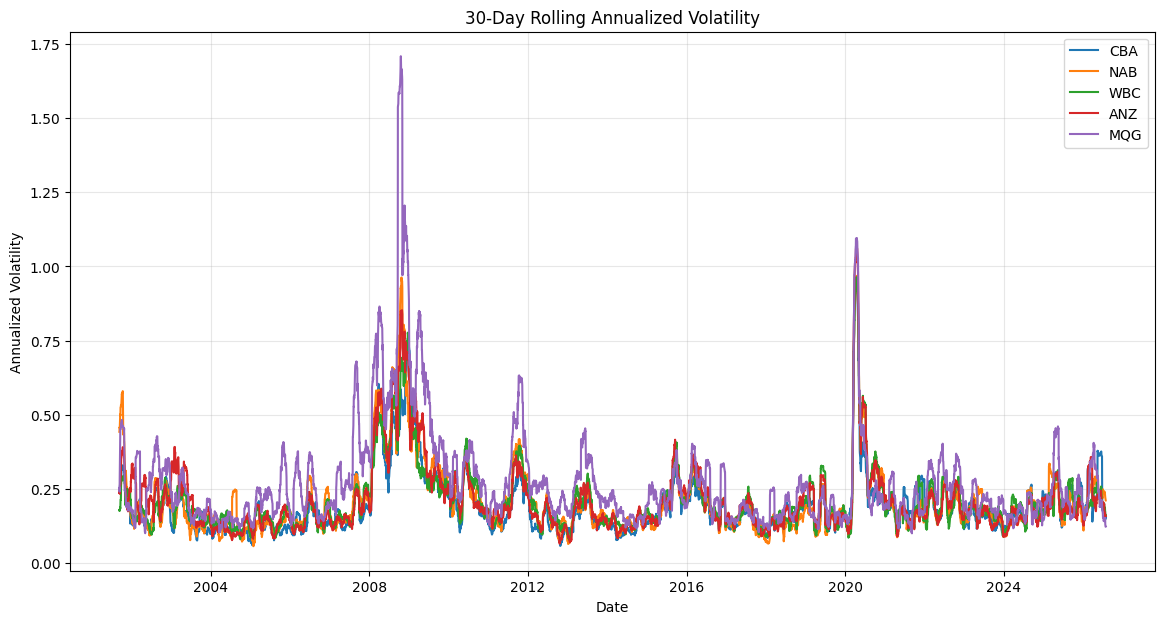

In [12]:
# Plotting the 30 day rolling annualized volatility for each bank
plt.figure(figsize=(14, 7))
for bank in banks_list:
    plt.plot(
        rolling_volatility_30.index,
        rolling_volatility_30[bank],
        label=bank
    )

plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

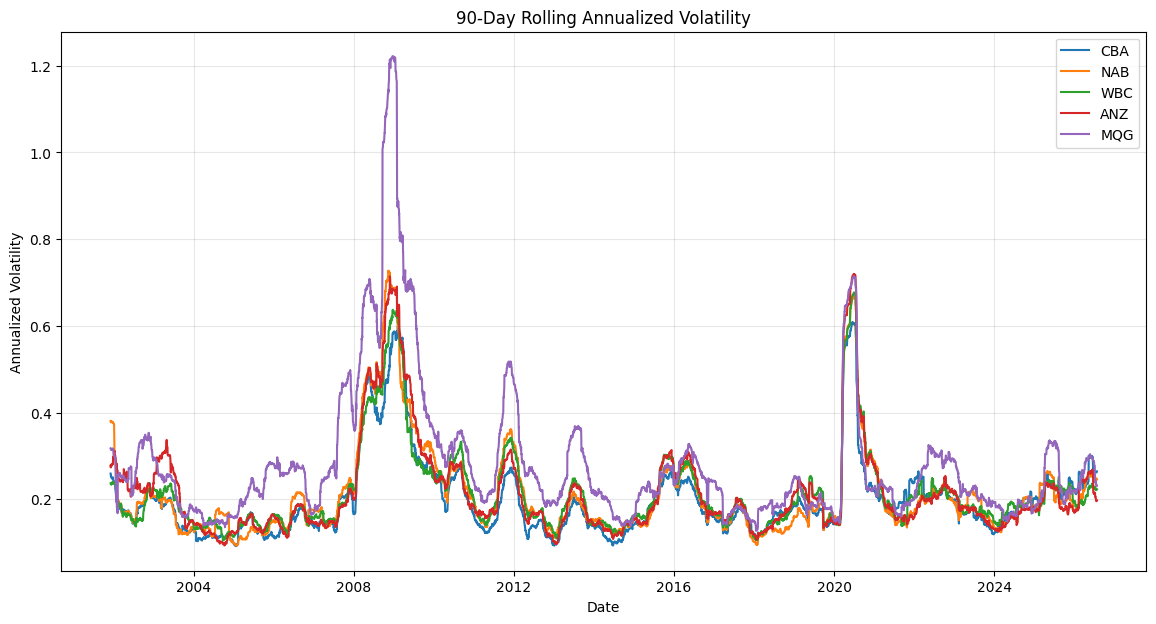

In [13]:
#90 days
plt.figure(figsize=(14, 7))
for bank in banks_list:
    plt.plot(
        rolling_volatility_90.index,
        rolling_volatility_90[bank],
        label=bank
    )

plt.title("90-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

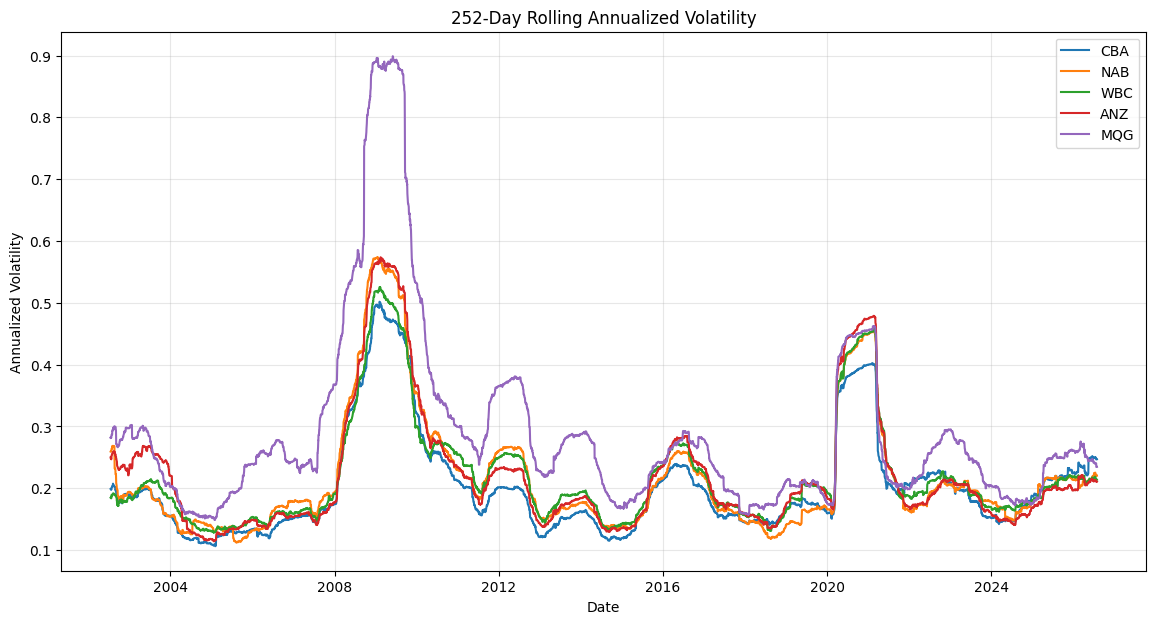

In [14]:
# 252 days
plt.figure(figsize=(14, 7))
for bank in banks_list:
    plt.plot(
        rolling_volatility_252.index,
        rolling_volatility_252[bank],
        label=bank
    )
plt.title("252-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [15]:
drawdowns = pd.DataFrame(index=price_df.index)
for bank in banks_list:
    running_max = price_df[bank].cummax()
    drawdowns[bank] = (
        price_df[bank] / running_max
    ) - 1

drawdowns.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-30,0.000000,0.0,0.000000,0.000000,0.000000
2001-07-31,-0.012056,0.0,-0.015087,-0.018263,0.000000
2001-08-01,0.000000,0.0,0.000000,0.000000,-0.020831
2001-08-02,0.000000,0.0,0.000000,0.000000,0.000000
2001-08-03,-0.021040,0.0,0.000000,0.000000,0.000000


In [16]:
maximum_drawdown = drawdowns.min()
maximum_drawdown_table = pd.DataFrame({
    "Maximum Drawdown": maximum_drawdown
})

maximum_drawdown_table["Maximum Drawdown (%)"] = (
    maximum_drawdown_table["Maximum Drawdown"] * 100
)
maximum_drawdown_table

,Maximum Drawdown,Maximum Drawdown (%)
CBA,-0.585301,-58.530099
NAB,-0.606603,-60.660340
WBC,-0.517353,-51.735314
ANZ,-0.586405,-58.640465
MQG,-0.817373,-81.737350


In [17]:
max_drawdown_dates = {}
for bank in banks_list:
    max_drawdown_dates[bank] = drawdowns[bank].idxmin()

max_drawdown_dates

{'CBA': Timestamp('2009-01-23 00:00:00'),
 'NAB': Timestamp('2009-03-09 00:00:00'),
 'WBC': Timestamp('2020-03-23 00:00:00'),
 'ANZ': Timestamp('2009-02-12 00:00:00'),
 'MQG': Timestamp('2009-03-02 00:00:00')}

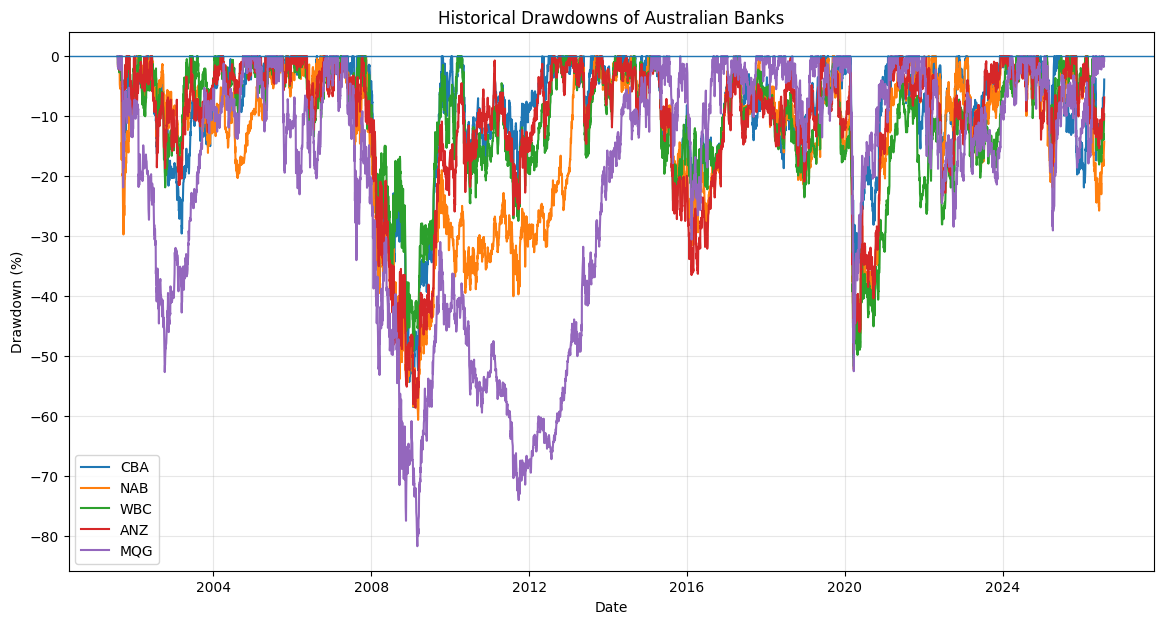

In [18]:
plt.figure(figsize=(14, 7))
for bank in banks_list:
    plt.plot(
        drawdowns.index,
        drawdowns[bank] * 100,
        label=bank
    )

plt.axhline(0, linewidth=1)
plt.title("Historical Drawdowns of Australian Banks")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [19]:
# calculate historical VaR at 95% and 99% confidence levels
historical_var_95 = -returns.quantile(0.05)
historical_var_99 = -returns.quantile(0.01)
historical_var_table = pd.DataFrame({
    "Historical VaR 95%": historical_var_95,
    "Historical VaR 99%": historical_var_99
})

historical_var_table * 100

,Historical VaR 95%,Historical VaR 99%
CBA,2.041500,3.820632
NAB,2.250056,4.253486
WBC,2.240959,3.955509
ANZ,2.237476,4.080825
MQG,2.862745,5.643263


In [20]:
mean_returns = returns.mean()
std_returns = returns.std()
z_95 = -1.645
z_99 = -2.326

parametric_var_95 = -(mean_returns + z_95 * std_returns)
parametric_var_99 = -(mean_returns + z_99 * std_returns)
parametric_var_table = pd.DataFrame({
    "Parametric VaR 95%": parametric_var_95,
    "Parametric VaR 99%": parametric_var_99
})
parametric_var_table * 100

,Parametric VaR 95%,Parametric VaR 99%
CBA,2.216893,3.158520
NAB,2.443509,3.470869
WBC,2.373613,3.376072
ANZ,2.473133,3.516518
MQG,3.295520,4.688644


In [21]:
historical_es_95 = {}
historical_es_99 = {}

for bank in banks_list:
    var_95_threshold = returns[bank].quantile(0.05)
    var_99_threshold = returns[bank].quantile(0.01)

    historical_es_95[bank] = (
        -returns[bank][returns[bank] <= var_95_threshold].mean()
    )

    historical_es_99[bank] = (
        -returns[bank][returns[bank] <= var_99_threshold].mean()
    )

es_table = pd.DataFrame({
    "Expected Shortfall 95%": historical_es_95,
    "Expected Shortfall 99%": historical_es_99
})

es_table * 100

,Expected Shortfall 95%,Expected Shortfall 99%
CBA,3.175910,5.460819
NAB,3.543940,6.039522
WBC,3.400240,5.537499
ANZ,3.499363,5.976974
MQG,4.766664,8.324689


In [22]:
risk_summary = pd.DataFrame(index=banks_list)
risk_summary["Annualized Volatility"] = annualized_volatility
risk_summary["Maximum Drawdown"] = maximum_drawdown
risk_summary["Historical VaR 95%"] = historical_var_95
risk_summary["Historical VaR 99%"] = historical_var_99
risk_summary["Parametric VaR 95%"] = parametric_var_95
risk_summary["Parametric VaR 99%"] = parametric_var_99
risk_summary["Expected Shortfall 95%"] = pd.Series(
    historical_es_95
)
risk_summary["Expected Shortfall 99%"] = pd.Series(
    historical_es_99
)
risk_summary

,Annualized Volatility,Maximum Drawdown,Historical VaR 95%,Historical VaR 99%,Parametric VaR 95%,Parametric VaR 99%,Expected Shortfall 95%,Expected Shortfall 99%
CBA,0.219499,-0.585301,0.020415,0.038206,0.022169,0.031585,0.031759,0.054608
NAB,0.239483,-0.606603,0.022501,0.042535,0.024435,0.034709,0.035439,0.060395
WBC,0.233679,-0.517353,0.022410,0.039555,0.023736,0.033761,0.034002,0.055375
ANZ,0.243219,-0.586405,0.022375,0.040808,0.024731,0.035165,0.034994,0.059770
MQG,0.324745,-0.817373,0.028627,0.056433,0.032955,0.046886,0.047667,0.083247


In [23]:

parametric_var_table.to_csv(
    "../data/processed/parametric_var_results.csv"
)
es_table.to_csv(
    "../data/processed/expected_shortfall_results.csv"
)
risk_summary.to_csv(
    "../data/processed/risk_metrics_summary.csv"
)
print("Parametric VaR, Expected Shortfall, and complete risk summary saved successfully.")

Parametric VaR, Expected Shortfall, and complete risk summary saved successfully.


In [24]:
historical_var_table.to_csv(
    "../data/processed/historical_var_results.csv"
)
print("Historical VaR results saved successfully.")

Historical VaR results saved successfully.


In [25]:
crisis_periods = {
    "GFC": ("2007-01-01", "2009-12-31"),
    "COVID": ("2020-02-01", "2020-06-30"),
    "Rate Hikes": ("2022-01-01", "2023-12-31")
}

In [26]:
crisis_results = []
for crisis, (start, end) in crisis_periods.items():
    crisis_returns = returns.loc[start:end]
    for bank in banks_list:
        bank_returns = crisis_returns[bank].dropna()
        volatility = bank_returns.std() * np.sqrt(252)
        historical_var = -bank_returns.quantile(0.05)
        historical_es = -bank_returns[
            bank_returns <= bank_returns.quantile(0.05)
        ].mean()

        crisis_results.append({
            "Crisis": crisis,
            "Bank": bank,
            "Annualized Volatility": volatility,
            "Historical VaR 95%": historical_var,
            "Expected Shortfall 95%": historical_es
        })

crisis_metrics = pd.DataFrame(crisis_results)
crisis_metrics

,Crisis,Bank,Annualized Volatility,Historical VaR 95%,Expected Shortfall 95%
0,GFC,CBA,0.355761,0.035110,0.049709
1,GFC,NAB,0.403099,0.041645,0.054966
2,GFC,WBC,0.362301,0.035056,0.049026
3,GFC,ANZ,0.400271,0.038686,0.055250
4,GFC,MQG,0.633036,0.057519,0.084902
5,COVID,CBA,0.570330,0.064169,0.078513
6,COVID,NAB,0.624159,0.068747,0.094281
7,COVID,WBC,0.629842,0.077102,0.093754
8,COVID,ANZ,0.670532,0.082841,0.101449
9,COVID,MQG,0.666950,0.073174,0.114248


In [27]:
crisis_volatility = crisis_metrics.pivot(
    index="Bank",
    columns="Crisis",
    values="Annualized Volatility"
)
crisis_volatility * 100

Crisis,COVID,GFC,Rate Hikes
Bank,,,
ANZ,67.053150,40.027112,18.834180
CBA,57.032992,35.576126,18.262458
MQG,66.695005,63.303636,25.393305
NAB,62.415861,40.309881,19.240597
WBC,62.984247,36.230102,19.437738


In [28]:
crisis_var = crisis_metrics.pivot(
    index="Bank",
    columns="Crisis",
    values="Historical VaR 95%"
)
crisis_var * 100

Crisis,COVID,GFC,Rate Hikes
Bank,,,
ANZ,8.284103,3.868621,2.089825
CBA,6.416922,3.510972,1.953977
MQG,7.317382,5.751950,2.698693
NAB,6.874741,4.164477,1.963507
WBC,7.710240,3.505639,1.977810


In [29]:
crisis_es = crisis_metrics.pivot(
    index="Bank",
    columns="Crisis",
    values="Expected Shortfall 95%"
)
crisis_es * 100

Crisis,COVID,GFC,Rate Hikes
Bank,,,
ANZ,10.144920,5.525009,2.731548
CBA,7.851271,4.970926,2.683162
MQG,11.424838,8.490172,3.714743
NAB,9.428131,5.496563,2.774624
WBC,9.375400,4.902632,2.823101


In [30]:
crisis_drawdowns = {}
for crisis, (start, end) in crisis_periods.items():
    crisis_prices = price_df.loc[start:end]
    crisis_drawdowns[crisis] = {}
    for bank in banks_list:
        running_max = crisis_prices[bank].cummax()
        bank_drawdown = (
            crisis_prices[bank] / running_max
        ) - 1

        crisis_drawdowns[crisis][bank] = bank_drawdown.min()

crisis_drawdown_table = pd.DataFrame(crisis_drawdowns)
crisis_drawdown_table * 100

,GFC,COVID,Rate Hikes
CBA,-58.530099,-39.015774,-19.464703
NAB,-60.660340,-49.361549,-21.043476
WBC,-49.167502,-45.370010,-20.767964
ANZ,-58.640465,-48.237894,-24.364963
MQG,-81.737350,-52.546619,-28.447367


In [31]:
wealth = (1 + returns).cumprod()
wealth.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-31,0.987944,1.013137,0.984913,0.981737,1.015521
2001-08-01,1.017079,1.041602,1.004310,1.013854,0.994366
2001-08-02,1.021835,1.054113,1.016522,1.020150,1.021126
2001-08-03,1.000335,1.057242,1.024281,1.045340,1.023943
2001-08-06,1.018754,1.059431,1.026580,1.042191,1.034366


In [32]:
running_max = wealth.cummax()
# Calculate drawdown
drawdown = (wealth - running_max) / running_max
drawdown.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-07-31,0.000000,0.0,0.0,0.000000,0.000000
2001-08-01,0.000000,0.0,0.0,0.000000,-0.020831
2001-08-02,0.000000,0.0,0.0,0.000000,0.000000
2001-08-03,-0.021040,0.0,0.0,0.000000,0.000000
2001-08-06,-0.003015,0.0,0.0,-0.003012,0.000000


In [33]:
max_drawdown_results = {}
for bank in drawdown.columns:
    
    max_dd = drawdown[bank].min()
    max_dd_date = drawdown[bank].idxmin()
    
    max_drawdown_results[bank] = {
        "Maximum Drawdown": max_dd,
        "Date": max_dd_date
    }
max_drawdown_table = pd.DataFrame(max_drawdown_results).T
max_drawdown_table

,Maximum Drawdown,Date
CBA,-0.585301,2009-01-23 00:00:00
NAB,-0.606603,2009-03-09 00:00:00
WBC,-0.517353,2020-03-23 00:00:00
ANZ,-0.586405,2009-02-12 00:00:00
MQG,-0.817373,2009-03-02 00:00:00


In [34]:
max_drawdown_table["Maximum Drawdown"] = (
    max_drawdown_table["Maximum Drawdown"] * 100
)
max_drawdown_table

,Maximum Drawdown,Date
CBA,-58.530099,2009-01-23 00:00:00
NAB,-60.66034,2009-03-09 00:00:00
WBC,-51.735314,2020-03-23 00:00:00
ANZ,-58.640465,2009-02-12 00:00:00
MQG,-81.73735,2009-03-02 00:00:00


In [35]:
max_drawdown_table.to_csv(
    "../data/processed/maximum_drawdown.csv"
)
print("Maximum drawdown results saved.")

Maximum drawdown results saved.


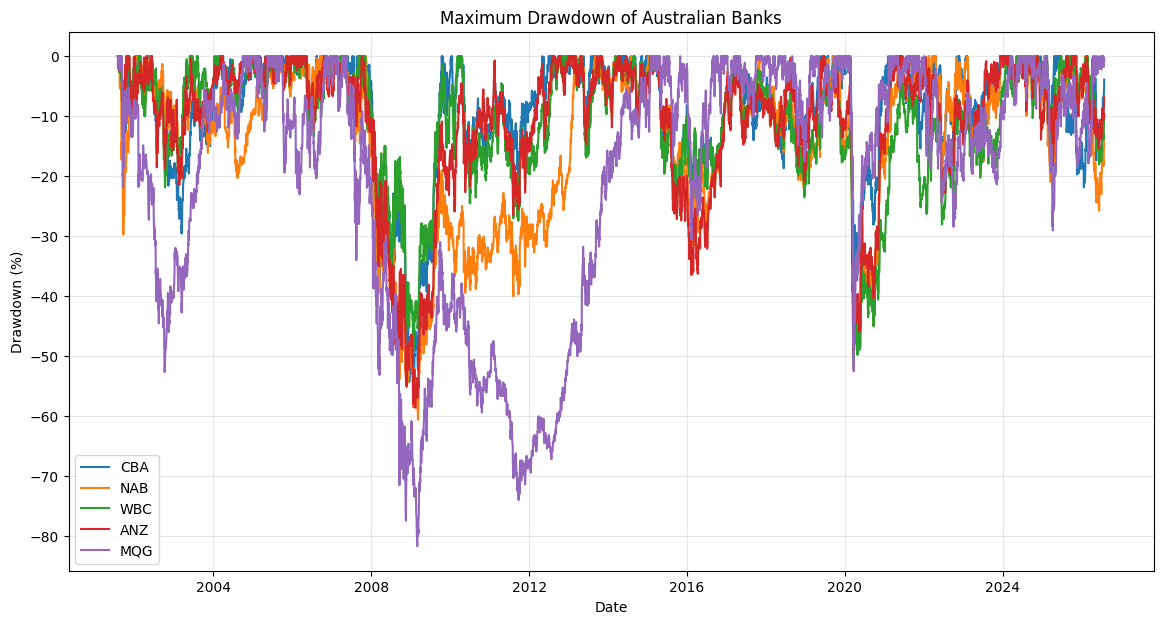

In [36]:
plt.figure(figsize=(14, 7))
for bank in drawdown.columns:
    plt.plot(drawdown.index, drawdown[bank] * 100, label=bank)

plt.title("Maximum Drawdown of Australian Banks")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()